# Plant Disease Dataset Analysis Notebook


In [ ]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted')

DATA_DIR = "data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")



### Parse dataset structure


In [156]:
plants = [
    "apple",
    "banana",
    "bean",
    "bell pepper",
    "blueberry",
    "basil",
    "broccoli",
    "cabbage",
    "cauliflower",
    "celery",
    "cherry",
    "citrus",
    "coffee",
    "corn",
    "cucumber",
    "garlic",
    "ginger",
    "grape",
    "lettuce",
    "maple",
    "peach",
    "plum",
    "potato",
    "raspberry",
    "rice",
    "soybean",
    "squash",
    "strawberry",
    "tobacco",
    "tomato",
    "wheat",
    "zucchini",
]
plants.sort(key=len, reverse=True)


def parse_dataset(root_dir):
    records = []
    images = []
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
                continue

            for plant in plants:
                if class_name.startswith(plant):
                    disease = class_name[len(plant) :].strip()
                    break
            records.append(
                {
                    "path": img_path,
                    "Name": img_name,
                    "plant": plant,
                    "disease": disease,
                    "class": class_name,
                }
            )

    return pd.DataFrame(records)


train_df = parse_dataset(TRAIN_DIR)
val_df = parse_dataset(VAL_DIR)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 7783
Val size: 390


### Basic statistics


In [157]:
print(f"Number of unique plants:   Train: {train_df["plant"].nunique()} Val: {val_df["plant"].nunique()}")
print(f"Number of unique diseases: Train: {train_df["disease"].nunique()} Val: {val_df["disease"].nunique()}")
print(f"Number of plant+disease:   Train: {train_df["class"].nunique()} Val: {val_df["class"].nunique()}")


Number of unique plants:   Train: 32 Val: 31
Number of unique diseases: Train: 39 Val: 39
Number of plant+disease:   Train: 82 Val: 71


### Disease distribution

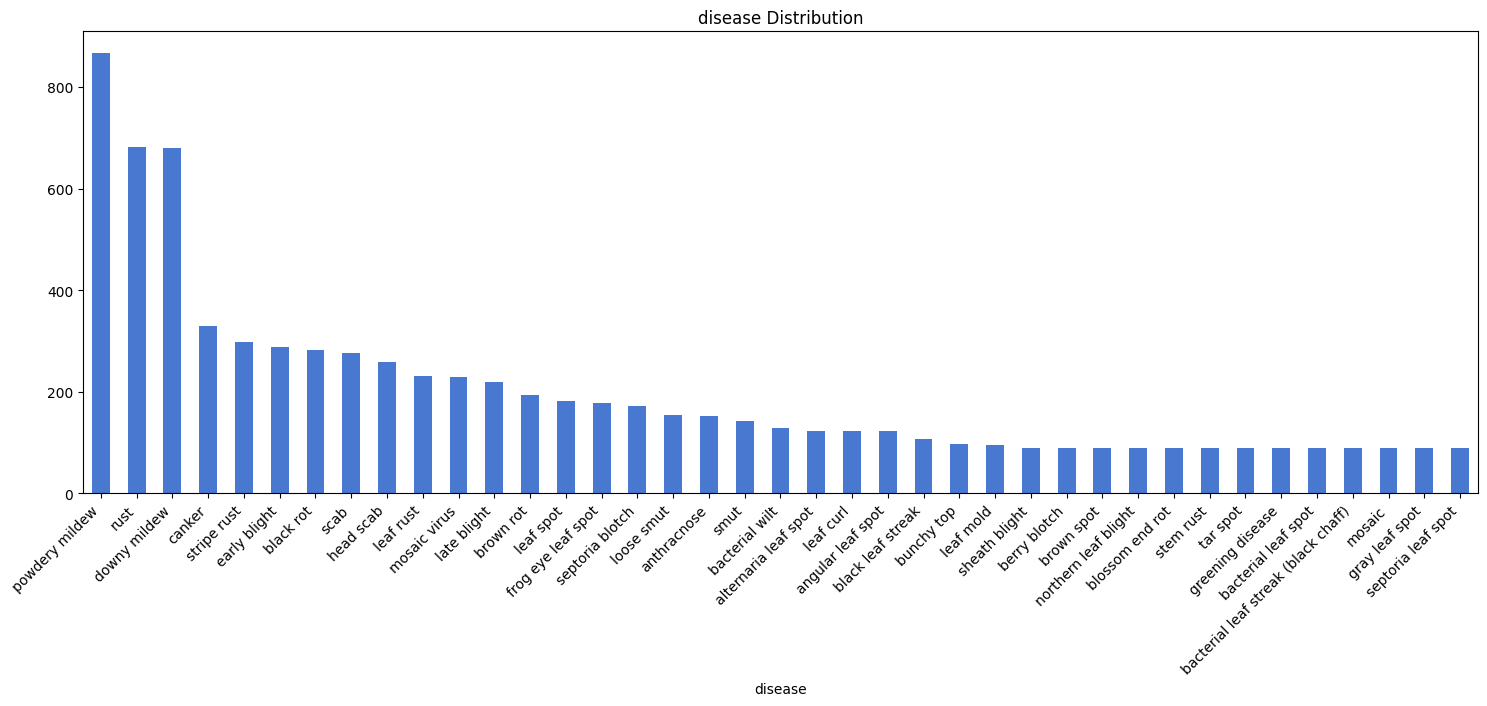

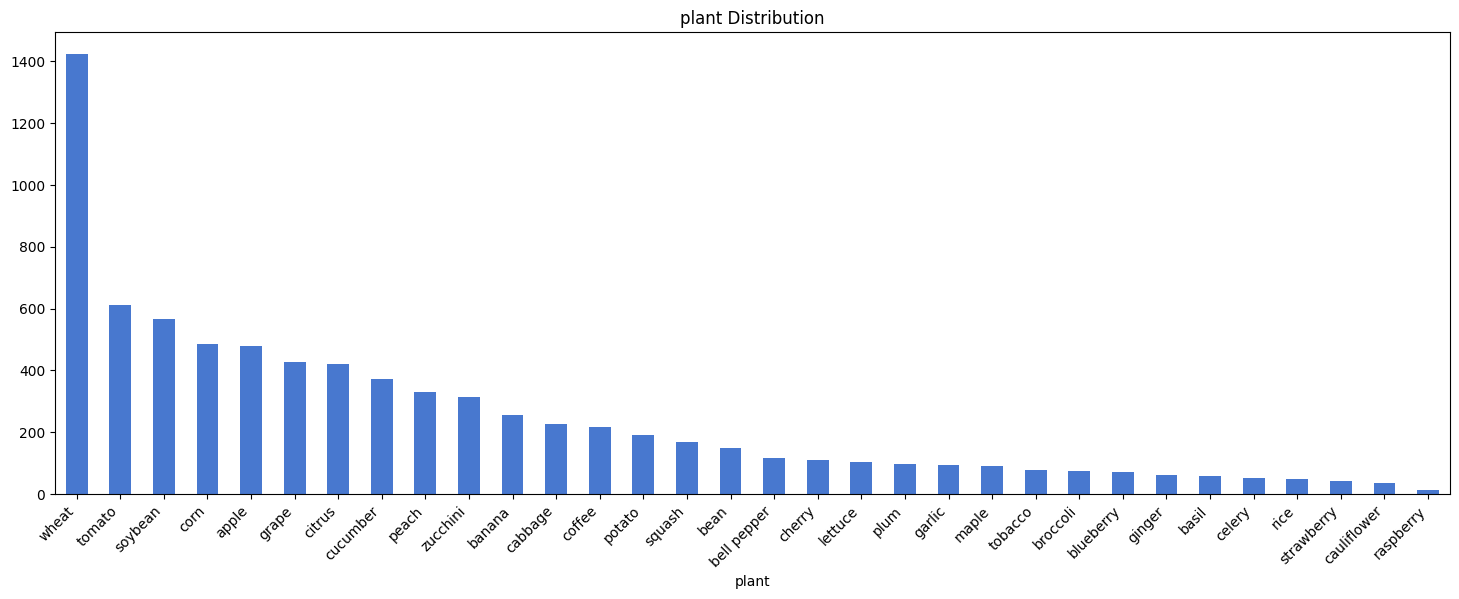

In [160]:
def plot_distribution(df, column, top_n=20):
    counts = df[column].value_counts()
    plt.figure(figsize=(18, 6))
    counts.plot(kind="bar")
    plt.title(f"{column} Distribution")
    plt.xticks(rotation=45, ha="right")
    plt.show()


plot_distribution(train_df, "disease")
plot_distribution(train_df, "plant")

### Check imbalance

In [161]:
print("Train set:")
print(train_df["disease"].value_counts().describe())
print("\nVal set:")
print(val_df["disease"].value_counts().describe())

Train set:
count     39.000000
mean     199.564103
std      175.999072
min       90.000000
25%       90.000000
50%      129.000000
75%      230.500000
max      866.000000
Name: count, dtype: float64

Val set:
count    39.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: count, dtype: float64


Some diseases are ~10x more frequent

model will bias toward frequent diseases

Validation set is good

 - exactly 10 samples per disease
 - completely balanced
 - Very small (390 total)

High variance → noisy metrics

### Disease generalization check
Which diseases appear across multiple plants?

In [162]:
disease_plants = (
    train_df.groupby("disease")["plant"].nunique().sort_values(ascending=False)
)
print("\nDiseases shared across multiple plants:")
print(disease_plants.head(20))


Diseases shared across multiple plants:
disease
rust                                   8
downy mildew                           7
powdery mildew                         6
mosaic virus                           5
anthracnose                            5
black rot                              4
leaf spot                              4
early blight                           3
alternaria leaf spot                   3
late blight                            2
leaf rust                              2
bacterial wilt                         2
sheath blight                          2
scab                                   2
brown spot                             2
brown rot                              2
bacterial leaf streak (black chaff)    1
bacterial leaf spot                    1
angular leaf spot                      1
berry blotch                           1
Name: plant, dtype: int64


Many diseases appear in only 1 plant

Model can learn  `plant`  -> `disease` shortcut \
not actual disease

### Image size analysis


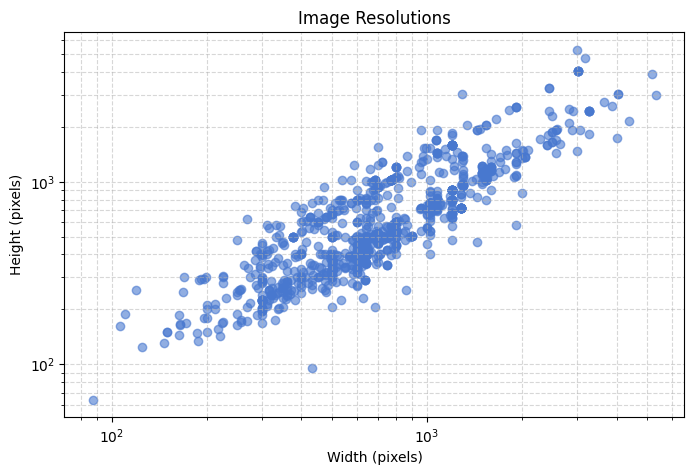

In [173]:
def get_image_sizes(df, sample_size=1000):
    sizes = []
    sample = df.sample(min(sample_size, len(df)),random_state=42)

    for path in sample["path"]:
        try:
            with Image.open(path) as img:
                sizes.append(img.size)
        except:
            continue

    return sizes

sizes = get_image_sizes(train_df)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.6)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Resolutions")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

Most images range from 400–1000px \
but long tail up to 5000+ px 

Dataset is highly inconsistent

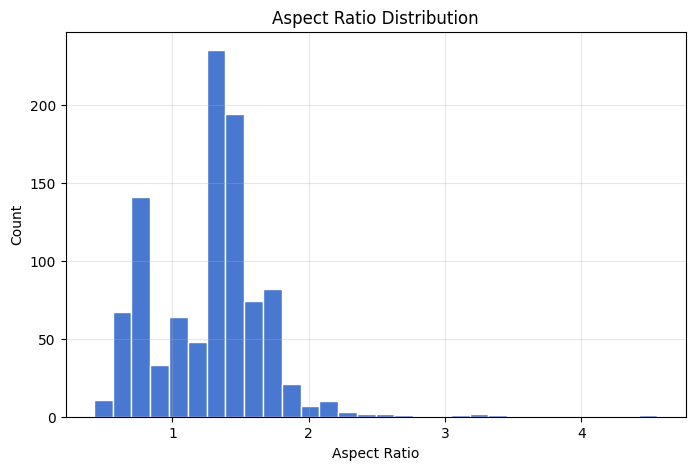

In [174]:
aspect_ratios = [w / h for w, h in sizes if h != 0]

plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=30,  edgecolor="white")

plt.xlabel("Aspect Ratio")
plt.ylabel("Count")
plt.title("Aspect Ratio Distribution")

plt.grid(alpha=0.3)
plt.show()

Most images are square or slightly rectangular. While a few exhibit extreme height \
or width, the overall aspect ratio variation remains moderate.


### Train vs Val leakage check

In [61]:
train_files = set(os.path.basename(p) for p in train_df["path"])
val_files = set(os.path.basename(p) for p in val_df["path"])

intersection = train_files.intersection(val_files)
print("Potential leakage (same filenames):", len(intersection))


Potential leakage (same filenames): 0
